In [1]:
import os
import re
import time
import random
import requests
import pandas as pd
import json
import threading

from pathlib import Path
from pydantic import BaseModel, Field
from helpers import get_content
from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from openai import OpenAI
from typing import List, Dict, Any

# List of additional GSE IDs to filter (drop)
# this gse ids are alreadt processed and live.
exclude_gse_ids = [
    "GSE96058",
    "GSE224564",
    "GSE229706",
    "GSE162682",
    "GSE181582",
    "GSE192667",
    "GSE120622",
    "GSE274975",
    "GSE184941",
    "GSE188715",
    "GSE148355",
    "GSE87340",
    "GSE216037",
    "GSE165808",
    "GSE60052",
    "GSE216490",
    "GSE144561",
    "GSE227378",
    "GSE201868",
    "GSE100797",
    "GSE133713",
    "GSE136961",
    "GSE150043",
]

print("STEP 0: Loading input data")
df = pd.read_csv('rna_seq_data/rna_seq_gds_with_publication_filtered.csv')
print(f"  Total rows in input publication CSV: {len(df)}")

survival_pmcids = set(pd.read_csv('rna_seq_data/survival-analysis-papers.csv')['pmcid'].tolist())
print(f"  Unique survival-analysis pmcids: {len(survival_pmcids)}")

print("STEP 1: Building gse_to_pmcid dict (keep only pmcids in survival_pmcids)")
gse_to_pmcid = {}
for _, row in df.iterrows():
    gseid = row['accession']
    pmcids = [pmcid for pmcid in row['pmcids'].split(';') if pmcid in survival_pmcids]
    if pmcids:
        gse_to_pmcid[gseid] = pmcids
print(f"  Entries in gse_to_pmcid after applying survival_pmcids: {len(gse_to_pmcid)}")

print("STEP 2: Filtering for candidate GSE IDs (intersection with gseids-candidates.csv)")
candidates_df = pd.read_csv('rna_seq_data/gseids-candidates.csv')
candidate_gseids = set(candidates_df['gseid'].unique())
print(f"  Unique candidate gseids from file: {len(candidate_gseids)}")

# Drop from gse_to_pmcid any gseid not in candidates
gse_to_pmcid = {gseid: pmcids for gseid, pmcids in gse_to_pmcid.items() if gseid in candidate_gseids}
print(f"  Remaining in gse_to_pmcid after intersection with candidate_gseids: {len(gse_to_pmcid)}")

print("STEP 3: Dropping specified gse_ids (exclude_gse_ids list)")
gse_to_pmcid = {gseid: pmcids for gseid, pmcids in gse_to_pmcid.items() if gseid not in exclude_gse_ids}
print(f"  Remaining in gse_to_pmcid after final exclusion: {len(gse_to_pmcid)}")

# gse_to_pmcid

STEP 0: Loading input data
  Total rows in input publication CSV: 10771
  Unique survival-analysis pmcids: 555
STEP 1: Building gse_to_pmcid dict (keep only pmcids in survival_pmcids)
  Entries in gse_to_pmcid after applying survival_pmcids: 586
STEP 2: Filtering for candidate GSE IDs (intersection with gseids-candidates.csv)
  Unique candidate gseids from file: 140
  Remaining in gse_to_pmcid after intersection with candidate_gseids: 140
STEP 3: Dropping specified gse_ids (exclude_gse_ids list)
  Remaining in gse_to_pmcid after final exclusion: 128


In [17]:
with open('gse_to_pmcid.json', 'w') as f:
    json.dump(gse_to_pmcid, f, indent=2)

In [2]:
import json
import re
import os
import time
from typing import List, Tuple
import GEOparse
import requests
from helpers import get_content

def _geo_soft_url(gse_id: str) -> str:
    """Build HTTPS URL for GEO series SOFT file."""
    gse_id = gse_id.upper().strip()
    range_subdir = re.sub(r"\d{1,3}$", "nnn", gse_id)
    return (
        f"https://ftp.ncbi.nlm.nih.gov/geo/series/"
        f"{range_subdir}/{gse_id}/soft/{gse_id}_family.soft.gz"
    )

def get_GEO_metadata(gse_id: str) -> Tuple[str, List[Tuple[str, str]]]:
    """
    Fetch GEO series metadata and per-sample metadata.
    Args:
        gse_id: GEO series id (e.g., "GSE12345").
    Returns:
        (series_metadata, samples_metadata) where series_metadata is a
        single string and samples_metadata is a list of (gsm_id, metadata).
    """
    gse_id = gse_id.upper().strip()
    destdir = "geo_cache"
    os.makedirs(destdir, exist_ok=True)
    filepath = os.path.join(destdir, f"{gse_id}_family.soft.gz")
    if not os.path.isfile(filepath):
        url = _geo_soft_url(gse_id)
        resp = requests.get(url)
        resp.raise_for_status()
        with open(filepath, "wb") as f:
            f.write(resp.content)
    gse = GEOparse.get_GEO(filepath=filepath, silent=True)
    series_metadata = gse._get_metadata_as_string()
    # Append explicit list of supplementary files
    sup_files: List[str] = []
    for key, values in gse.metadata.items():
        if "supplementary_file" in key and values:
            sup_files.extend(str(v).strip() for v in values if v)
    if sup_files:
        series_metadata += "\n\nSupplementary files:\n" + "\n".join(sup_files)
    samples_metadata: List[Tuple[str, str]] = []
    for idx, (gsm_id, gsm_data) in enumerate(gse.gsms.items()):
        if idx < 2:
            samples_metadata.append((gsm_id, gsm_data._get_metadata_as_string()))
        else:
            char_keys = [
                k for k in gsm_data.metadata.keys()
                if k.startswith("characteristics_ch")
            ]
            char_data = []
            for key in sorted(char_keys):
                channel_data = gsm_data.metadata[key]
                char_data.extend([f"{key}: {item}" for item in channel_data])
            samples_metadata.append((gsm_id, ", ".join(char_data)))
    return series_metadata, samples_metadata


USER_PROMPT = """GEO SERIES METADATA:
{series_metadata}

GEO SAMPLE METADATA:
{samples_metadata_str}
--------------------------------
{articles}"""


SYSTEM_PROMPT = """You are an expert biomedical metadata classification assistant.

# OBJECTIVE
Analyze the provided GEO series metadata and GEO sample metadata to determine whether the provided samples are explicitly annotated with a usable **survival endpoint**.

Any provided paper text may be used only to clarify ambiguous metadata labels. The paper must **not** be used as independent evidence that a survival endpoint exists if that endpoint is not actually represented in the provided GEO metadata/sample annotations.

# CLASSIFICATION TARGET
Determine whether the provided GEO metadata/sample annotations contain a survival endpoint for the provided samples.

# CLASSIFICATION CRITERIA
A survival endpoint is considered present only if the provided GEO metadata/sample annotations contain evidence of a **time-to-event outcome** for the provided samples, such as:

- overall survival
- progression-free survival
- disease-free survival
- recurrence-free survival
- event-free survival
- cancer-specific survival
- metastasis-free survival
- similar survival or time-to-event endpoints

*Note on variability:* GEO metadata formats are highly variable. Be permissive of unconventional naming conventions, combined fields (e.g., a single field containing both time and event), or implicit data structures, as long as it represents a time-to-event survival outcome. **Survival data may be directly in sample characteristics, or explicitly described as attached clinical data in series/sample descriptive fields.**

**IMPORTANT EXCLUSION - BINARY THRESHOLDS ARE NOT SURVIVAL DATA:** 
A binary or categorical variable indicating whether an event occurred before a fixed timepoint (e.g., "5-year survival status: Dead/Alive", "Progression within 12 months: Yes/No", or "Relapse: True/False" without a corresponding time duration) does **NOT** count as a survival endpoint. The metadata must contain or explicitly reference **continuous/numerical time data** (the actual duration of time until the event or censoring occurred).

## Critical constraint
The **source of truth is the provided GEO metadata/sample annotations**. **If the GEO metadata explicitly states that survival data is provided in an attached supplementary file for the samples, this counts as the endpoint being present.**
Use the paper text only to interpret unclear metadata labels. For example, if a sample field name is ambiguous, the paper may help explain that the field refers to a survival endpoint.

Important Exclusion: A binary categorical variable indicating whether an event occurred before a fixed timepoint (e.g., "5-year survival status: Dead/Alive", or "Progression within 12 months: Yes/No") does NOT count as a survival endpoint. The metadata must contain or reference actual continuous/numerical time data (the duration of time until the event or censoring occurred).

However:
- If the paper mentions survival analysis but the provided GEO metadata/sample annotations do **not** contain the corresponding sample-level or metadata-level survival label (or explicit reference to an attached clinical file containing it), do **not** classify as `YES`.
- A paper-only mention of survival outcomes is **not sufficient**.
- Return `YES` only when the survival endpoint is actually represented in the provided GEO metadata/sample annotations, either directly or through a paper-supported interpretation of an existing metadata field.

# INSTRUCTIONS
1. Review the provided GEO series metadata and GEO sample metadata first. **Pay attention to both sample-level characteristics and series/sample-level descriptive fields indicating attached clinical data.**
2. Identify whether the provided samples are annotated with a survival endpoint (time-to-event data).
3. Use the paper text only to clarify ambiguous metadata fields already present in the GEO metadata.
4. Assign exactly one label:
   - `YES`: The provided GEO metadata/sample annotations contain evidence of a survival endpoint.
   - `NO`: The provided GEO metadata/sample annotations clearly do not contain a survival endpoint.
   - `NA`: The provided GEO metadata/sample annotations are too incomplete, ambiguous, or contradictory to determine this confidently.
5. Provide a brief justification of **no more than 3 sentences**. 
6. In your justification, explicitly state the exact metadata field names you found (or note their absence) to support your decision.

# FORMATTING RULES
- Do **not** invent, normalize, or paraphrase metadata field names or evidence.
- Base the decision strictly on the provided GEO metadata/sample annotations.
- Do **not** classify `YES` based on paper text alone.
- If the paper describes survival outcomes but the provided GEO metadata/sample annotations do not contain the corresponding label or field, classify as `NO` or `NA`, whichever is more appropriate.
- Keep the justification brief, concrete, and evidence-based.
- Output **valid JSON only**.
- Do NOT wrap the JSON in markdown code blocks (e.g., do not use ```json ... ```). Output the raw JSON object starting with { and ending with }.
- Do not include any text before or after the JSON object.

# OUTPUT JSON SCHEMA
{
  "justification": "Brief evidence-based explanation citing specific metadata fields (max 3 sentences).",
  "classification": "YES" | "NO" | "NA"
}"""


input_prompts = []

for gseid, pmcids in gse_to_pmcid.items():
    time.sleep(1)
    series_metadata, samples_metadata = get_GEO_metadata(gseid)
    samples_metadata_str = "\n".join([f"{gsm_id}: {gsm_data}" for gsm_id, gsm_data in samples_metadata])

    articles = []
    for pmcid in pmcids:
        content = get_content(f'rna_seq_data/bioCjson_raw/{pmcid}.json.gz')
        research_article = f"\n**ARTICLE {pmcid}**\n\nTITLE:{content['TITLE']}\nABSTRACT:{content['ABSTRACT']}\nCONTENT:{content['CONTENT'] + content['FIG_CAPTIONS'] + content['SUPPL']}"
        articles.append(research_article)

    user_prompt = USER_PROMPT.format(
        series_metadata=series_metadata,
        samples_metadata_str=samples_metadata_str,
        articles='\n'.join(articles)
    )

    input_prompts.append({
        "gseid": gseid,
        "pmcids": pmcids,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt}
        ]
    })

with open("rna_seq_data/survival-endpoint-geo-metadata-prompts.jsonl", "w") as f:
    for prompt in input_prompts:
        f.write(json.dumps(prompt) + "\n")


In [3]:
import statistics
import tiktoken

prompts_path = "rna_seq_data/survival-endpoint-geo-metadata-prompts.jsonl"
enc = tiktoken.get_encoding("o200k_base")

user_token_counts = []

with open(prompts_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        item = json.loads(line)

        user_text = "\n".join(
            str(m.get("content", ""))
            for m in item.get("messages", [])
            if m.get("role") == "user"
        )

        user_token_counts.append(len(enc.encode(user_text)))

total_prompts = len(user_token_counts)
total_user_tokens = sum(user_token_counts)
mean_tokens = statistics.mean(user_token_counts) if user_token_counts else 0
median_tokens = statistics.median(user_token_counts) if user_token_counts else 0

system_prompt_tokens_single = len(enc.encode(SYSTEM_PROMPT))
total_system_tokens = system_prompt_tokens_single * total_prompts

print(f"Tokenizer: {enc.name}")
print(f"Total prompts: {total_prompts}")
print(f"Total user tokens: {total_user_tokens:,}")
print(f"Average user tokens per prompt: {mean_tokens:.2f}")
print(f"Median user tokens per prompt: {median_tokens:.2f}")
print(f"System prompt tokens (single): {system_prompt_tokens_single:,}")
print(f"Total system tokens (reused across all prompts): {total_system_tokens:,}")

Tokenizer: o200k_base
Total prompts: 128
Total user tokens: 2,502,491
Average user tokens per prompt: 19550.71
Median user tokens per prompt: 15939.00
System prompt tokens (single): 1,034
Total system tokens (reused across all prompts): 132,352


In [19]:
class ClassificationResponse(BaseModel):
    justification: str = Field(description="Brief evidence-based explanation citing specific metadata fields (max 3 sentences).")
    classification: str = Field(description="YES | NO | NA")


# OpenAI reads OPENAI_API_KEY from the environment.
client_openai = OpenAI()

# Optional OpenRouter client.
client_openrouter = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY", "not-configured")
)


def _call_openai(messages: List[Dict[str, Any]]) -> Any:
    # Responses API uses "input" + "input_text" content type
    formatted_messages = []
    for msg in messages:
        formatted_messages.append({
            "role": msg["role"],
            "content": [{"type": "input_text", "text": msg["content"]}],
        })

    # client.responses.parse is the correct method for:
    # - structured output (text_format param)
    # - reasoning effort
    # - input_text content type
    resp = client_openai.responses.parse(
        model="gpt-5.4-2026-03-05", # gpt-5-nano-2025-08-07 , gpt-5-mini-2025-08-07 gpt-5.4-2026-03-05
        input=formatted_messages,
        text_format=ClassificationResponse,  # Pydantic model for structured output
        reasoning={"effort": "medium"},
        service_tier="flex"
    )

    # Result is accessed via resp.output_parsed, not resp.choices[0]
    return resp.output_parsed, resp.usage


def _call_openrouter(messages: List[Dict[str, Any]]) -> Any:
    # IMPORTANT: Use standard create(), not responses.parse() for OSS models
    resp = client_openrouter.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=messages,
        # To force DeepInfra and ensure consistent pricing:
        extra_body={
            "provider": {
                "order": ["DeepInfra"],
                "allow_fallbacks": False
            },
            # Since we can't use 'text_format', we use 'response_format'
            "response_format": {"type": "json_object"},
            "reasoning": {"effort": "medium"}  # ✅ Inside extra_body
        }
    )

    content = resp.choices[0].message.content
    if not isinstance(content, str):
        raise TypeError(f"Expected JSON string content, got {type(content).__name__}")

    content = content.strip()
    if not content:
        raise ValueError("OpenRouter returned empty content")

    parsed = ClassificationResponse.model_validate_json(content)

    usage = resp.usage
    input_tokens = getattr(usage, "input_tokens", None)
    if input_tokens is None:
        input_tokens = getattr(usage, "prompt_tokens", None)

    output_tokens = getattr(usage, "output_tokens", None)
    if output_tokens is None:
        output_tokens = getattr(usage, "completion_tokens", None)

    token_details = getattr(usage, "input_tokens_details", None)
    if token_details is None:
        token_details = getattr(usage, "prompt_tokens_details", None)

    usage_details = {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cached_tokens": getattr(token_details, "cached_tokens", None) if token_details is not None else None,
        "total_tokens": getattr(usage, "total_tokens", None),
    }

    return parsed, usage_details



input_prompts = []
with open(prompts_path, "r") as f:
    for line in f:
        if line.strip():
            input_prompts.append(json.loads(line))

results_file = f"{prompts_path.replace('prompts.jsonl', 'results-5.4.jsonl')}"
computed_gseid = set()

if os.path.exists(results_file):
    with open(results_file, "r") as f:
        for line in f:
            if not line.strip():
                continue
            result_data = json.loads(line)
            computed_gseid.add(str(result_data.get("gseid")).strip())

pending_prompts = [
    p for p in input_prompts
    if p.get("gseid") not in computed_gseid
]

print(f"Found {len(computed_gseid)} already computed submissions")
print(f"Processing {len(pending_prompts)} remaining submissions")

# raise Exception("Stop here")

MAX_WORKERS = 4
write_lock = threading.Lock()


def _worker(prompt_data, file_handle):
    gseid = prompt_data["gseid"]
    messages = prompt_data["messages"]

    try:
        parsed, usage = _call_openai(messages)
        # parsed, usage = _call_openrouter(messages)  # For OpenRouter, use this line instead
        usage_data = usage.model_dump() if hasattr(usage, "model_dump") else usage
        result_data = {
            "gseid": gseid,
            "response": parsed.model_dump(),
            "usage": usage_data,
        }

        line = json.dumps(result_data, ensure_ascii=False) + "\n"
        with write_lock:
            file_handle.write(line)
            file_handle.flush()

        return {"ok": True, "gseid": gseid}
    except Exception as e:
        return {"ok": False, "gseid": gseid, "error": str(e)}

results_count = 0
error_count = 0
completed_count = 0

with open(results_file, "a", encoding="utf-8") as out_f:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(_worker, p, out_f) for p in pending_prompts]

        for future in as_completed(futures):
            completed_count += 1
            info = future.result()

            if info["ok"]:
                results_count += 1
                if results_count % 10 == 0:
                    print(f"Processed {results_count} submissions...")
            else:
                error_count += 1
                print(f"Error processing {info['gseid']}: {info['error']}")

print(f"Completed! Processed {results_count} new submissions ({error_count} errors)")


Found 1 already computed submissions
Processing 13 remaining submissions
Processed 10 submissions...
Completed! Processed 13 new submissions (0 errors)


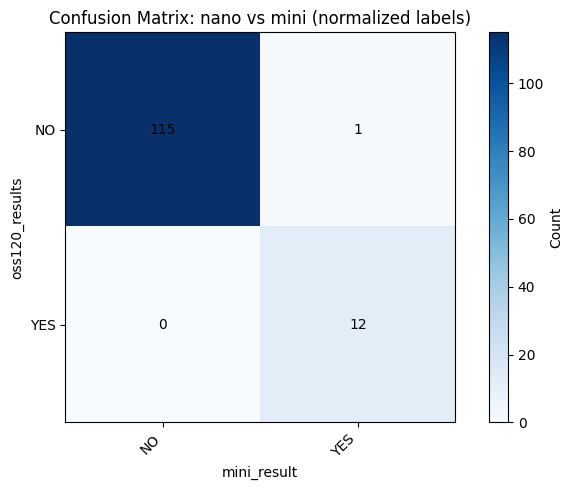

mini_result
NO     115
YES     13
Name: count, dtype: int64


In [2]:
# OPTIONAL ANALYSIS: skip this cell and the cells below it on a first run.
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

oss120_path = Path("rna_seq_data/survival-endpoint-geo-metadata-results-oss120.jsonl")
mini_path = Path("rna_seq_data/survival-endpoint-geo-metadata-results-mini.jsonl")
gpt54_path = Path("rna_seq_data/survival-endpoint-geo-metadata-results-5.4.jsonl")


def _normalize_label(label):

#     if label is None:
#         return None

#     value = " ".join(str(label).strip().upper().split())

#     if "CLINICAL" in value or "PATIENT" in value or "BIOSPECIMEN" in value:
#         return "CLINICAL SPECIMEN"
#     if "LAB" in value or "EXPERIMENT" in value or "MODEL" in value:
#         return "LAB MODEL"
#     if "UNCLEAR" in value or "INSUFFICIENT" in value or "VAGUE" in value:
#         return "UNCLEAR"

    return label


def _load_classifications(path: Path) -> dict:
    records = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            gseid = item.get("gseid")
            classification = _normalize_label((item.get("response") or {}).get("classification"))
            if gseid:
                records[str(gseid).strip()] = classification
    return records


oss120_results = _load_classifications(oss120_path)
mini_results = _load_classifications(mini_path)

all_gseids = sorted(set(mini_results) | set(mini_results))
df_results = pd.DataFrame(
    {
        "gseid": all_gseids,
        "oss120_result": [oss120_results.get(gseid) for gseid in all_gseids],
        "mini_result": [mini_results.get(gseid) for gseid in all_gseids],
    }
)

cm = pd.crosstab(
    df_results["oss120_result"].fillna("MISSING"),
    df_results["mini_result"].fillna("MISSING"),
    dropna=False,
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_title("Confusion Matrix: nano vs mini (normalized labels)")
ax.set_xlabel("mini_result")
ax.set_ylabel("oss120_results")
ax.set_xticks(range(len(cm.columns)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm.index)))
ax.set_yticklabels(cm.index)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm.iat[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

print(df_results['mini_result'].value_counts())

In [3]:

mismatch = df_results["mini_result"] != df_results["oss120_result"]
mismatch_gseids = set(df_results.loc[mismatch, "gseid"].tolist())
print(f"Number of pmcids where normalized mini_result != normalized oss120_result: {len(mismatch_gseids)}")


Number of pmcids where normalized mini_result != normalized oss120_result: 1


In [4]:
mismatch_gseids

{'GSE189672'}

In [5]:
both_yes = df_results[
    (df_results["mini_result"] == "YES") & (df_results["oss120_result"] == "YES")
]["gseid"].tolist()
print("GSEIDs where both mini_result and oss120_result are YES:", both_yes)

GSEIDs where both mini_result and oss120_result are YES: ['GSE102073', 'GSE113863', 'GSE131521', 'GSE162643', 'GSE164150', 'GSE165656', 'GSE167573', 'GSE183924', 'GSE188812', 'GSE218527', 'GSE241876', 'GSE78220']


In [6]:
both_no = df_results[
    (df_results["mini_result"] == "NO") & (df_results["oss120_result"] == "NO")
]["gseid"].tolist()
print("GSEIDs where both mini_result and oss120_result are NO:", both_no)

GSEIDs where both mini_result and oss120_result are NO: ['GSE101108', 'GSE101638', 'GSE101927', 'GSE102118', 'GSE104730', 'GSE105130', 'GSE111085', 'GSE115525', 'GSE115821', 'GSE121810', 'GSE122630', 'GSE127559', 'GSE128500', 'GSE130078', 'GSE133039', 'GSE136401', 'GSE138581', 'GSE141335', 'GSE143415', 'GSE143897', 'GSE143940', 'GSE144269', 'GSE147352', 'GSE147493', 'GSE147932', 'GSE151594', 'GSE151666', 'GSE153348', 'GSE154938', 'GSE155398', 'GSE155945', 'GSE156699', 'GSE156902', 'GSE157601', 'GSE158413', 'GSE162960', 'GSE163899', 'GSE164665', 'GSE167977', 'GSE168204', 'GSE171059', 'GSE172022', 'GSE172356', 'GSE174330', 'GSE175462', 'GSE176178', 'GSE178398', 'GSE179252', 'GSE179351', 'GSE179730', 'GSE181273', 'GSE181559', 'GSE182031', 'GSE183202', 'GSE183984', 'GSE184336', 'GSE186332', 'GSE188249', 'GSE190967', 'GSE192959', 'GSE193066', 'GSE193080', 'GSE193157', 'GSE193946', 'GSE196576', 'GSE198136', 'GSE198545', 'GSE198650', 'GSE199361', 'GSE207194', 'GSE208218', 'GSE208858', 'GSE209